In [1]:
import os

device_map = "auto"  #fcy

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl

from argparse import Namespace

import torch
import requests
import numpy as np

import cv2
from PIL import Image

import utils_model
import utils_gradio
import utils_attn


# Update rcParams to disable axes
mpl.rcParams['axes.spines.left'] = False
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.bottom'] = False
mpl.rcParams['xtick.bottom'] = False
mpl.rcParams['xtick.top'] = False
mpl.rcParams['xtick.labelbottom'] = False
mpl.rcParams['ytick.left'] = False
mpl.rcParams['ytick.right'] = False
mpl.rcParams['ytick.labelleft'] = False


[2025-04-16 17:30:19,411] [INFO] [real_accelerator.py:239:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/usr/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/usr/bin/ld: cannot find -lcufile: No such file or directory
collect2: error: ld returned 1 exit status


In [2]:
# model_name_or_path = "microsoft/Phi-3.5-vision-instruct" 
# model_name_or_path = "llava-hf/llava-1.5-7b-hf"
model_name_or_path = "Intel/llava-gemma-2b"
# model_name_or_path = "llava-hf/llava-v1.6-mistral-7b-hf"
# model_name_or_path = "Qwen/Qwen2.5-VL-3B-Instruct"

args = Namespace(
    model_name_or_path=model_name_or_path,
    load_4bit=False,
    load_8bit=False,
    device_map=device_map,
)
processor, model = utils_model.get_processor_model(args)

utils_gradio.processor = processor
utils_gradio.model = model

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Loading checkpoint shards: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  1.63steps/s]


In [3]:
processor.patch_size = 14
processor

LlavaProcessor:
- image_processor: CLIPImageProcessor {
  "crop_size": {
    "height": 336,
    "width": 336
  },
  "do_center_crop": true,
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.48145466,
    0.4578275,
    0.40821073
  ],
  "image_processor_type": "CLIPImageProcessor",
  "image_std": [
    0.26862954,
    0.26130258,
    0.27577711
  ],
  "processor_class": "LlavaProcessor",
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 336
  }
}

- tokenizer: GemmaTokenizerFast(name_or_path='Intel/llava-gemma-2b', vocab_size=256000, model_max_length=1000000000000000019884624838656, is_fast=True, padding_side='left', truncation_side='right', special_tokens={'bos_token': '<bos>', 'eos_token': '<eos>', 'unk_token': '<unk>', 'pad_token': '<pad>', 'additional_special_tokens': ['<start_of_turn>', '<end_of_turn>']}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedTo

In [4]:
model

LlavaForConditionalGeneration(
  (vision_tower): CLIPVisionModel(
    (vision_model): CLIPVisionTransformer(
      (embeddings): CLIPVisionEmbeddings(
        (patch_embedding): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
        (position_embedding): Embedding(577, 1024)
      )
      (pre_layrnorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (encoder): CLIPEncoder(
        (layers): ModuleList(
          (0-23): 24 x CLIPEncoderLayer(
            (self_attn): CLIPSdpaAttention(
              (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
              (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
              (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
              (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
            )
            (layer_norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPMLP(
              (activation_fn): Q

In [5]:
prompt = "What animal is this and what is on the left of it?"
image_file = "http://images.cocodataset.org/val2017/000000039769.jpg"
raw_image = Image.open(requests.get(image_file, stream=True).raw)

image_process_mode = "Default"
state, _, _, _ = utils_gradio.add_text(None, prompt, raw_image, image_process_mode)

In [6]:
temperature = 0.1
top_p = 0.7
max_new_tokens = 20

state, _ = utils_gradio.lvlm_bot(state, temperature, top_p, max_new_tokens)

recovered_image = state.recovered_image
fig = plt.figure()
plt.imshow(recovered_image)
role, message = state.messages[-1]
print(f'{role}: {message}')

You may have used the wrong order for inputs. `images` should be passed before `text`. The `images` and `text` inputs will be swapped. This behavior will be deprecated in transformers v4.47.
CLIPModel is using CLIPSdpaAttention, but `torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:1 and cuda:0!

In [5]:
def show_cam_on_image(img: np.ndarray,
                      mask: np.ndarray,
                      colormap: int = cv2.COLORMAP_JET) -> np.ndarray:
    """ This function overlays the cam mask on the image as an heatmap.
    By default the heatmap is in BGR format.
    :param img: The base image in RGB or BGR format.
    :param mask: The cam mask.
    :param use_rgb: Whether to use an RGB or BGR heatmap, this should be set to True if 'img' is in RGB format.
    :param colormap: The OpenCV colormap to be used.
    :returns: The default image with the cam overlay.
    """
    heatmap = cv2.applyColorMap(np.uint8(255 * mask), colormap)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    heatmap = np.float32(heatmap) / 255

    if np.max(img) > 1:
        raise Exception(
            "The input image should np.float32 in the range [0, 1]")

    cam = heatmap + img
    cam = cam / np.max(cam)
    return np.uint8(255 * cam)

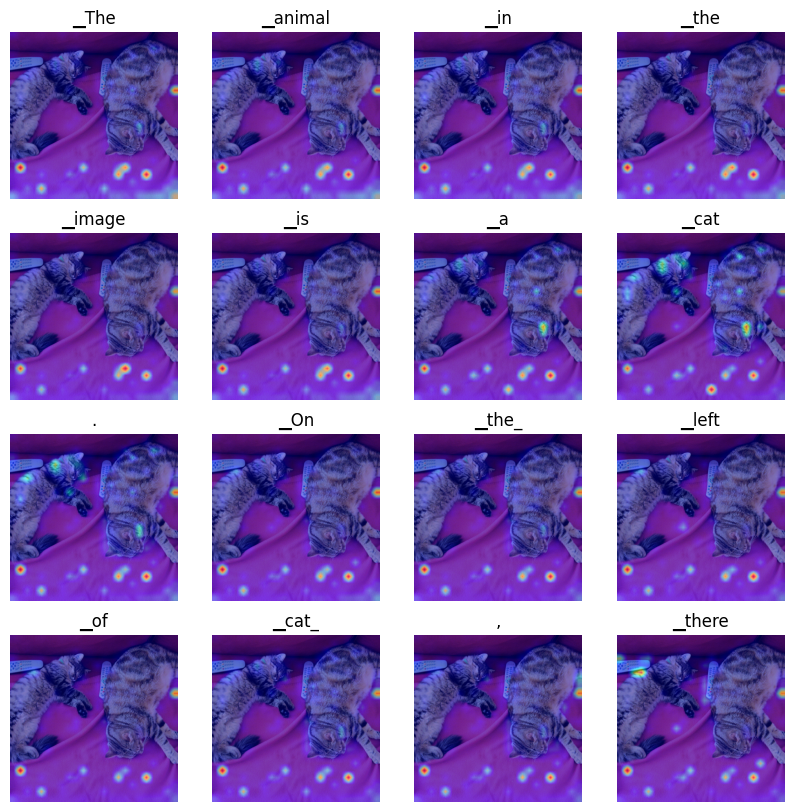

In [6]:
type_selector = 'llama'
fn_attention = state.attention_key + '_relevancy.pt'
recovered_image = state.recovered_image
img_idx = state.image_idx
word_rel_maps = torch.load(fn_attention)

word_rel_map = word_rel_maps[type_selector]
image_list = []


fig, axes = plt.subplots(4, 4, figsize=(10,10))
# fig.tight_layout()

for ax, (rel_key, rel_map) in zip(axes.ravel(), word_rel_map.items()):

    if (rel_map.shape[-1] != 577):
        rel_map = rel_map[-1,:][img_idx:img_idx+576].reshape(1,1,24,24).float()
    else:
        rel_map = rel_map[0,1:].reshape(1,1,24,24).float()
        
    rel_map_upscaled = torch.nn.functional.interpolate(rel_map, scale_factor=14, mode='bilinear')
    rel_map_upscaled = (rel_map_upscaled - rel_map_upscaled.min()) / (rel_map_upscaled.max() - rel_map_upscaled.min())
    rel_map_upscaled = rel_map_upscaled.squeeze(0).squeeze(0)
    
    original_image = np.array(recovered_image)
    original_image = (original_image - original_image.min()) / (original_image.max() - original_image.min())
    vis = show_cam_on_image(original_image, rel_map_upscaled.cpu().numpy())
    # vis = Image.from_array(vis)
    
    ax.imshow(vis)
    ax.set_title(f'{rel_key}')